In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import subprocess
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

RAW_DIR = Path("../../data/raw/pickup")
OUT_DIR = Path("../../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("RAW_DIR exists:", RAW_DIR.exists())
print("OUT_DIR exists:", OUT_DIR.exists())
print("RAW_DIR contents:", list(RAW_DIR.iterdir()))

RAW_DIR exists: True
OUT_DIR exists: True
RAW_DIR contents: [PosixPath('../../data/raw/pickup/pickup_cq.csv'), PosixPath('../../data/raw/pickup/pickup_jl.csv'), PosixPath('../../data/raw/pickup/pickup_sh.csv'), PosixPath('../../data/raw/pickup/pickup_hz.csv'), PosixPath('../../data/raw/pickup/pickup_yt.csv')]


In [ ]:
sample = pd.read_csv(RAW_DIR / "pickup_sh.csv", nrows=3)
print("Columns:", list(sample.columns))
print("\nShape preview (3 rows):")
print(sample)

Columns: ['order_id', 'region_id', 'city', 'courier_id', 'accept_time', 'time_window_start', 'time_window_end', 'lng', 'lat', 'aoi_id', 'aoi_type', 'pickup_time', 'pickup_gps_time', 'pickup_gps_lng', 'pickup_gps_lat', 'accept_gps_time', 'accept_gps_lng', 'accept_gps_lat', 'ds']

Shape preview (3 rows):
   order_id  region_id      city  courier_id     accept_time  \
0   2349637          0  Shanghai        1448  07-08 08:13:00   
1   4867696          0  Shanghai        1448  07-21 08:14:00   
2   5691514          0  Shanghai        1448  07-12 07:40:00   

  time_window_start time_window_end        lng       lat  aoi_id  aoi_type  \
0    07-08 09:00:00  07-08 11:00:00  121.52223  30.90747      46        14   
1    07-21 09:00:00  07-21 11:00:00  121.52223  30.90742      46        14   
2    07-12 17:00:00  07-12 19:00:00  121.52229  30.90731      46        14   

      pickup_time pickup_gps_time  pickup_gps_lng  pickup_gps_lat  \
0  07-08 10:10:00  07-08 10:10:00       121.52208        

In [ ]:
print("Unique cities:", sample['city'].unique())
print("Unique region_ids:", sample['region_id'].unique())

sample100 = pd.read_csv(RAW_DIR / "pickup_sh.csv", nrows=1000)
print("\nregion_id unique values:", sample100['region_id'].nunique())
print("city unique values:", sample100['city'].nunique())
print(sample100.groupby('city')['region_id'].unique())

Unique cities: <ArrowStringArray>
['Shanghai']
Length: 1, dtype: str
Unique region_ids: [0]

region_id unique values: 1
city unique values: 1
city
Shanghai    [0]
Name: region_id, dtype: object


In [4]:
for fname in RAW_DIR.iterdir():
    df = pd.read_csv(fname, usecols=['city', 'region_id'], nrows=1000)
    print(f"{fname.name:20s} → city: {df['city'].unique().tolist()}  region_id: {df['region_id'].unique().tolist()}")

pickup_cq.csv        → city: ['Chongqing']  region_id: [3]
pickup_jl.csv        → city: ['Jilin']  region_id: [9]
pickup_sh.csv        → city: ['Shanghai']  region_id: [0]
pickup_hz.csv        → city: ['Hangzhou']  region_id: [1]
pickup_yt.csv        → city: ['Yantai']  region_id: [16]


In [5]:
gps_cols = ['pickup_gps_lng', 'pickup_gps_lat', 'accept_gps_lng', 'accept_gps_lat']

for fname in sorted(RAW_DIR.iterdir()):
    df = pd.read_csv(fname, usecols=gps_cols)
    total = len(df)
    print(f"\n{fname.name}")
    for col in gps_cols:
        null_pct = df[col].isnull().mean() * 100
        print(f"  {col:25s} → {null_pct:.1f}% null")


pickup_cq.csv
  pickup_gps_lng            → 27.5% null
  pickup_gps_lat            → 27.5% null
  accept_gps_lng            → 46.7% null
  accept_gps_lat            → 46.7% null

pickup_hz.csv
  pickup_gps_lng            → 35.1% null
  pickup_gps_lat            → 35.1% null
  accept_gps_lng            → 51.0% null
  accept_gps_lat            → 51.0% null

pickup_jl.csv
  pickup_gps_lng            → 16.1% null
  pickup_gps_lat            → 16.1% null
  accept_gps_lng            → 31.3% null
  accept_gps_lat            → 31.3% null

pickup_sh.csv
  pickup_gps_lng            → 31.0% null
  pickup_gps_lat            → 31.0% null
  accept_gps_lng            → 45.9% null
  accept_gps_lat            → 45.9% null

pickup_yt.csv
  pickup_gps_lng            → 20.9% null
  pickup_gps_lat            → 20.9% null
  accept_gps_lng            → 35.9% null
  accept_gps_lat            → 35.9% null


In [7]:
CITY_FILES = {
    "Shanghai":  "pickup_sh.csv",
    "Hangzhou":  "pickup_hz.csv",
    "Chongqing": "pickup_cq.csv",
    "Yantai":    "pickup_yt.csv",
    "Jilin":     "pickup_jl.csv",
}

frames = []
for city, fname in CITY_FILES.items():
    df_city = pd.read_csv(RAW_DIR / fname, low_memory=False)
    print(f"{city:12s} → {len(df_city):>10,} rows")
    frames.append(df_city)

df = pd.concat(frames, ignore_index=True)
print(f"\nTotal: {len(df):,} rows")
print(f"Columns: {list(df.columns)}")

Shanghai     →  1,424,406 rows
Hangzhou     →  2,130,456 rows
Chongqing    →  1,172,703 rows
Yantai       →  1,146,781 rows
Jilin        →    261,801 rows

Total: 6,136,147 rows
Columns: ['order_id', 'region_id', 'city', 'courier_id', 'accept_time', 'time_window_start', 'time_window_end', 'lng', 'lat', 'aoi_id', 'aoi_type', 'pickup_time', 'pickup_gps_time', 'pickup_gps_lng', 'pickup_gps_lat', 'accept_gps_time', 'accept_gps_lng', 'accept_gps_lat', 'ds']


In [8]:
print("Null counts in full dataset:")
print(df[['lng', 'lat', 'accept_gps_lng', 'accept_gps_lat', 
          'pickup_gps_lng', 'pickup_gps_lat']].isnull().sum())
print(f"\nTotal rows: {len(df):,}")

Null counts in full dataset:
lng                     0
lat                     0
accept_gps_lng    2782371
accept_gps_lat    2782371
pickup_gps_lng    1792862
pickup_gps_lat    1792862
dtype: int64

Total rows: 6,136,147


In [ ]:
sub = df[df['accept_gps_time'].notna()].copy()

at = pd.to_datetime(sub['accept_time'], format='%m-%d %H:%M:%S', errors='coerce')
agt = pd.to_datetime(sub['accept_gps_time'], format='%m-%d %H:%M:%S', errors='coerce')

diff_min = (at - agt).dt.total_seconds() / 60

print(f"Rows where accept_gps_time is not null: {len(sub):,}")
print(f"Rows where accept_gps_time is NULL:     {df['accept_gps_time'].isnull().sum():,}")
print(f"\naccept_time - accept_gps_time (minutes):")
print(diff_min.describe())
print(f"\nExactly equal: {(diff_min == 0).sum():,}")
print(f"Differ by <=5 min: {(diff_min.abs() <= 5).sum():,}")

Rows where accept_gps_time is not null: 3,353,776
Rows where accept_gps_time is NULL:     2,782,371

accept_time - accept_gps_time (minutes):
count    3.353776e+06
mean     9.230968e-01
std      1.940000e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      1.000000e+01
dtype: float64

Exactly equal: 2,167,135
Differ by <=5 min: 3,174,306


In [10]:
df = df.drop(columns=['accept_gps_time'])
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (6136147, 18)
Columns: ['order_id', 'region_id', 'city', 'courier_id', 'accept_time', 'time_window_start', 'time_window_end', 'lng', 'lat', 'aoi_id', 'aoi_type', 'pickup_time', 'pickup_gps_time', 'pickup_gps_lng', 'pickup_gps_lat', 'accept_gps_lng', 'accept_gps_lat', 'ds']


In [11]:
df = df.drop(columns=['region_id', 'pickup_gps_time'])
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (6136147, 16)
Columns: ['order_id', 'city', 'courier_id', 'accept_time', 'time_window_start', 'time_window_end', 'lng', 'lat', 'aoi_id', 'aoi_type', 'pickup_time', 'pickup_gps_lng', 'pickup_gps_lat', 'accept_gps_lng', 'accept_gps_lat', 'ds']


In [12]:
print("ds range:", df['ds'].min(), "→", df['ds'].max())
print("\nds sample values:", sorted(df['ds'].unique())[:5], "...", sorted(df['ds'].unique())[-5:])
print("\nSample accept_time values:")
print(df['accept_time'].head(3).tolist())
print("\nNumber of unique ds:", df['ds'].nunique())

ds range: 501 → 1031

ds sample values: [np.int64(501), np.int64(502), np.int64(503), np.int64(504), np.int64(505)] ... [np.int64(1027), np.int64(1028), np.int64(1029), np.int64(1030), np.int64(1031)]

Sample accept_time values:
['07-08 08:13:00', '07-21 08:14:00', '07-12 07:40:00']

Number of unique ds: 184


In [ ]:
result = subprocess.run(
    ['wc', '-l', '../../data/raw/pickup_five_cities.csv'],
    capture_output=True, text=True
)
print("Raw wc -l output:", result.stdout.strip())

lines = int(result.stdout.strip().split()[0])
print(f"\npickup_five_cities.csv rows (minus header): {lines - 1:,}")
print(f"Our concatenated df rows:                  {len(df):,}")
print(f"Difference:                                {(lines - 1) - len(df):,}")

Raw wc -l output: 531116 ../../data/raw/pickup_five_cities.csv

pickup_five_cities.csv rows (minus header): 531,115
Our concatenated df rows:                  6,136,147
Difference:                                -5,605,032


In [14]:
DATETIME_COLS = ['accept_time', 'time_window_start', 'time_window_end', 'pickup_time']

for col in DATETIME_COLS:
    df[col] = pd.to_datetime(df[col], format='%m-%d %H:%M:%S', errors='coerce')

print("Parse complete.\n")
print("Null counts after parse (NaT = failed parse):")
print(df[DATETIME_COLS].isnull().sum())
print("\nDtypes:")
print(df[DATETIME_COLS].dtypes)
print("\nSample:")
print(df[DATETIME_COLS].head(3))

Parse complete.

Null counts after parse (NaT = failed parse):
accept_time          0
time_window_start    0
time_window_end      0
pickup_time          0
dtype: int64

Dtypes:
accept_time          datetime64[us]
time_window_start    datetime64[us]
time_window_end      datetime64[us]
pickup_time          datetime64[us]
dtype: object

Sample:
          accept_time   time_window_start     time_window_end  \
0 1900-07-08 08:13:00 1900-07-08 09:00:00 1900-07-08 11:00:00   
1 1900-07-21 08:14:00 1900-07-21 09:00:00 1900-07-21 11:00:00   
2 1900-07-12 07:40:00 1900-07-12 17:00:00 1900-07-12 19:00:00   

          pickup_time  
0 1900-07-08 10:10:00  
1 1900-07-21 10:10:00  
2 1900-07-12 17:22:00  


In [ ]:
delay = (df['pickup_time'] - df['time_window_end']).dt.total_seconds() / 60

print("Raw delay_minutes (pickup_time - time_window_end):")
print(delay.describe(percentiles=[.01, .25, .5, .75, .80, .95, .99]))

print(f"\nDelays < -720 min (12+ hrs early, suspicious): {(delay < -720).sum():,}")
print(f"Delays > 720 min (12+ hrs late, suspicious):   {(delay > 720).sum():,}")

Raw delay_minutes (pickup_time - time_window_end):
count    6.136147e+06
mean    -1.044253e+02
std      1.729194e+02
min     -6.282000e+03
1%      -7.790000e+02
25%     -1.210000e+02
50%     -8.700000e+01
75%     -5.000000e+01
80%     -4.100000e+01
95%     -1.200000e+01
99%      4.800000e+01
max      5.420300e+04
dtype: float64

Delays < -720 min (12+ hrs early, suspicious): 67,864
Delays > 720 min (12+ hrs late, suspicious):   3,375


Rows within ±720 min: 6,064,908 (98.84%)
Rows outside ±720 min: 71,239 (1.16%)


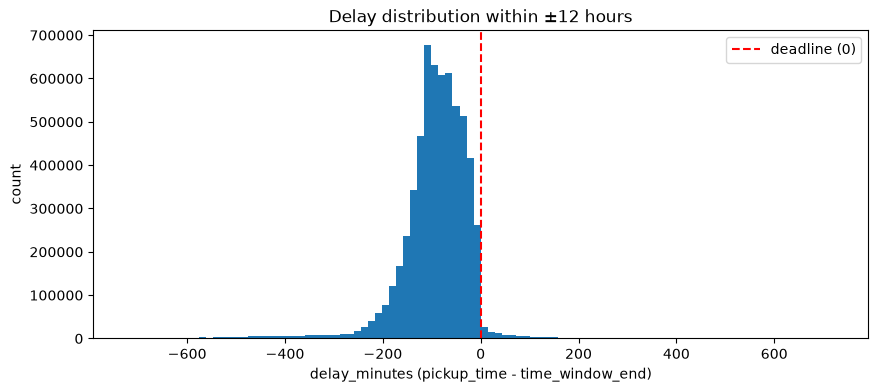

In [ ]:
delay = (df['pickup_time'] - df['time_window_end']).dt.total_seconds() / 60

mask = (delay >= -720) & (delay <= 720)
print(f"Rows within ±720 min: {mask.sum():,} ({mask.mean()*100:.2f}%)")
print(f"Rows outside ±720 min: {(~mask).sum():,} ({(~mask).mean()*100:.2f}%)")

plt.figure(figsize=(10, 4))
plt.hist(delay[mask], bins=100, edgecolor='none')
plt.axvline(0, color='red', linestyle='--', label='deadline (0)')
plt.xlabel('delay_minutes (pickup_time - time_window_end)')
plt.ylabel('count')
plt.title('Delay distribution within ±12 hours')
plt.legend()
plt.show()

In [ ]:
acc_hour = df['accept_time'].dt.hour
pick_hour = df['pickup_time'].dt.hour
end_hour = df['time_window_end'].dt.hour

late_window = end_hour >= 22
print(f"Orders with window ending 22:00-23:59: {late_window.sum():,} ({late_window.mean()*100:.2f}%)")

early_pickup = pick_hour <= 4
print(f"Pickups happening 00:00-04:59:          {early_pickup.sum():,} ({early_pickup.mean()*100:.2f}%)")

delay = (df['pickup_time'] - df['time_window_end']).dt.total_seconds() / 60
midnight_suspect = late_window & (delay < -720)
print(f"Likely midnight-crossing rows:          {midnight_suspect.sum():,} ({midnight_suspect.mean()*100:.4f}%)")

Orders with window ending 22:00-23:59: 74,448 (1.21%)
Pickups happening 00:00-04:59:          53 (0.00%)
Likely midnight-crossing rows:          23,553 (0.3838%)


In [ ]:
df['delay_minutes'] = (df['pickup_time'] - df['time_window_end']).dt.total_seconds() / 60

before = len(df)
df = df[(df['delay_minutes'] >= -720) & (df['delay_minutes'] <= 720)].copy()
after = len(df)
print(f"Dropped {before - after:,} outlier rows ({(before-after)/before*100:.2f}%)")
print(f"Remaining: {after:,} rows")

threshold = df['delay_minutes'].quantile(0.80)
print(f"\n80th percentile delay threshold: {threshold:.2f} minutes")

df['is_disrupted'] = (df['delay_minutes'] > threshold).astype(int)
print(f"\nLabel distribution:")
print(df['is_disrupted'].value_counts())
print(f"\nDisruption rate: {df['is_disrupted'].mean()*100:.2f}%")

Dropped 71,239 outlier rows (1.16%)
Remaining: 6,064,908 rows

80th percentile delay threshold: -41.00 minutes

Label distribution:
is_disrupted
0    4866890
1    1198018
Name: count, dtype: int64

Disruption rate: 19.75%


In [19]:
print("If disrupted = picked up AFTER deadline (delay > 0):")
late = (df['delay_minutes'] > 0)
print(f"  Disrupted: {late.sum():,} ({late.mean()*100:.2f}%)")

for t in [0, 15, 30, 60]:
    rate = (df['delay_minutes'] > t).mean() * 100
    print(f"  delay > {t:>3} min late: {rate:.2f}% disrupted")

If disrupted = picked up AFTER deadline (delay > 0):
  Disrupted: 110,276 (1.82%)
  delay >   0 min late: 1.82% disrupted
  delay >  15 min late: 1.42% disrupted
  delay >  30 min late: 1.17% disrupted
  delay >  60 min late: 0.83% disrupted


In [ ]:
df['is_disrupted'] = (df['delay_minutes'] > 0).astype(int)

print("Final label distribution:")
print(df['is_disrupted'].value_counts())
print(f"\nDisruption rate: {df['is_disrupted'].mean()*100:.2f}%")
print(f"Positive cases:  {df['is_disrupted'].sum():,}")

Final label distribution:
is_disrupted
0    5954632
1     110276
Name: count, dtype: int64

Disruption rate: 1.82%
Positive cases:  110,276


In [21]:
print("Current shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nDtypes:")
print(df.dtypes)
print("\nNull check on key columns:")
print(df[['order_id', 'city', 'courier_id', 'accept_time', 
          'time_window_end', 'pickup_time', 'aoi_id', 'ds', 
          'delay_minutes', 'is_disrupted']].isnull().sum())

Current shape: (6064908, 18)

Columns: ['order_id', 'city', 'courier_id', 'accept_time', 'time_window_start', 'time_window_end', 'lng', 'lat', 'aoi_id', 'aoi_type', 'pickup_time', 'pickup_gps_lng', 'pickup_gps_lat', 'accept_gps_lng', 'accept_gps_lat', 'ds', 'delay_minutes', 'is_disrupted']

Dtypes:
order_id                      int64
city                            str
courier_id                    int64
accept_time          datetime64[us]
time_window_start    datetime64[us]
time_window_end      datetime64[us]
lng                         float64
lat                         float64
aoi_id                        int64
aoi_type                      int64
pickup_time          datetime64[us]
pickup_gps_lng              float64
pickup_gps_lat              float64
accept_gps_lng              float64
accept_gps_lat              float64
ds                            int64
delay_minutes               float64
is_disrupted                  int64
dtype: object

Null check on key columns:
order_id  

In [ ]:
dupes = df['order_id'].duplicated().sum()
print(f"Duplicate order_ids: {dupes:,}")
if dupes > 0:
    print("  ⚠ order_id is NOT unique - investigate before Step 3")

train_rows = (df['ds'] <= 950).sum()
test_rows  = (df['ds'] >= 951).sum()
print(f"\nFuture split preview:")
print(f"  Train (ds<=950): {train_rows:,} ({train_rows/len(df)*100:.1f}%)")
print(f"  Test  (ds>=951): {test_rows:,} ({test_rows/len(df)*100:.1f}%)")

print(f"\nDisruption rate by split:")
print(f"  Train: {df[df['ds']<=950]['is_disrupted'].mean()*100:.2f}%")
print(f"  Test:  {df[df['ds']>=951]['is_disrupted'].mean()*100:.2f}%")

Duplicate order_ids: 0

Future split preview:
  Train (ds<=950): 4,946,313 (81.6%)
  Test  (ds>=951): 1,118,595 (18.4%)

Disruption rate by split:
  Train: 1.82%
  Test:  1.79%


In [ ]:
OUT_DIR = Path("../../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUT_DIR / "pickup_clean.parquet"
df.to_parquet(out_path, index=False, engine="pyarrow")

print(f"Saved → {out_path}")
print(f"Shape: {df.shape}")
print(f"File size: {out_path.stat().st_size / 1e6:.1f} MB")

check = pd.read_parquet(out_path)
print(f"\nReload check: {check.shape} — {'OK' if check.shape == df.shape else 'MISMATCH'}")

Saved → ../../data/processed/pickup_clean.parquet
Shape: (6064908, 18)
File size: 179.1 MB

Reload check: (6064908, 18) — OK
